# Exploratory Data Analysis (EDA) for READ-MAS Datasets

This notebook performs EDA on all raw and processed datasets to inform:
- FAISS index chunking strategy
- Data diversity by domain and programming language
- Requirements distribution by size
- Domain/project type classification for golden selection

## Datasets Analyzed
| Dataset | Source | Format | Purpose |
|---------|--------|--------|---------|
| PROMISE | CSV | 45 projects, labeled requirements | FAISS index |
| PURE | PDF/DOCX/HTML/XML | 61 docs + 18 XML | FAISS index + goldens |
| DevBench | Markdown | 22 Python, Java, C++, and JavaScript projects (PRD+UML+arch) | Goldens (designer/documenter/read/single) |
| rSDE-Bench | Markdown | 45 website + 8 game specs | Goldens (collector/analyzer) |

## Library Imports and Constants Setup

In [1]:
import pandas as pd
import json
import re
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
import xmltodict

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Base paths
BASE = Path('../../datasets')
PROMISE_PATH = BASE / 'promise' / 'PROMISE-relabeled-NICE.csv'
PURE_REQ_PATH = BASE / 'pure' / 'requirements'
PURE_XML_PATH = BASE / 'pure' / 'xml'
DEVBENCH_PYTHON_PATH = BASE / 'DevBench' / 'benchmark_data' / 'python'
DEVBENCH_JS_PATH = BASE / 'DevBench' / 'benchmark_data' / 'javascript'
DEVBENCH_JAVA_PATH = BASE / 'DevBench' / 'benchmark_data' / 'java'
DEVBENCH_CPP_PATH = BASE / 'DevBench' / 'benchmark_data' / 'cpp'
RSDE_WEBSITE_PATH = BASE / 'rSDE-Bench' / 'website'
RSDE_GAME_PATH = BASE / 'rSDE-Bench' / 'game'
PREPROCESSED_PATH = BASE / 'preprocessed'
KNOWLEDGE_PATH = BASE / 'software-engineer-gpt' / 'knowledge.md'

print('All paths resolved.')

All paths resolved.


---
## 1. PROMISE Dataset EDA

In [2]:
promise = pd.read_csv(PROMISE_PATH)
print(f'Total rows: {len(promise)}')
print(f'Unique projects: {promise["ProjectID"].nunique()}')
print(f'Columns: {list(promise.columns)}')
promise.head()

Total rows: 622
Unique projects: 15
Columns: ['ProjectID', 'RequirementText', 'IsFunctional', 'IsQuality', 'Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 'Security (SE)', 'Usability (US)', 'Other (OT)']


,ProjectID,RequirementText,IsFunctional,IsQuality,Availability (A),Fault Tolerance (FT),Legal (L),Look & Feel (LF),Maintainability (MN),Operability (O),Performance (PE),Portability (PO),Scalability (SC),Security (SE),Usability (US),Other (OT)
0,1,'The system shall refresh the display every 60...,1,1,0,0,0,0,0,0,1,0,0,0,0,0
1,1,'The application shall match the color of the ...,0,1,0,0,1,1,0,0,0,0,0,0,0,0
2,1,'If projected the data must be readable. On a ...,0,1,0,0,0,1,0,0,0,0,0,0,1,0
3,1,'The product shall be available during normal ...,0,1,1,0,0,0,0,0,0,0,0,0,0,0
4,1,'If projected the data must be understandable....,0,1,0,0,0,1,0,0,0,0,0,0,1,0


### 1.1 Requirements per Project Distribution

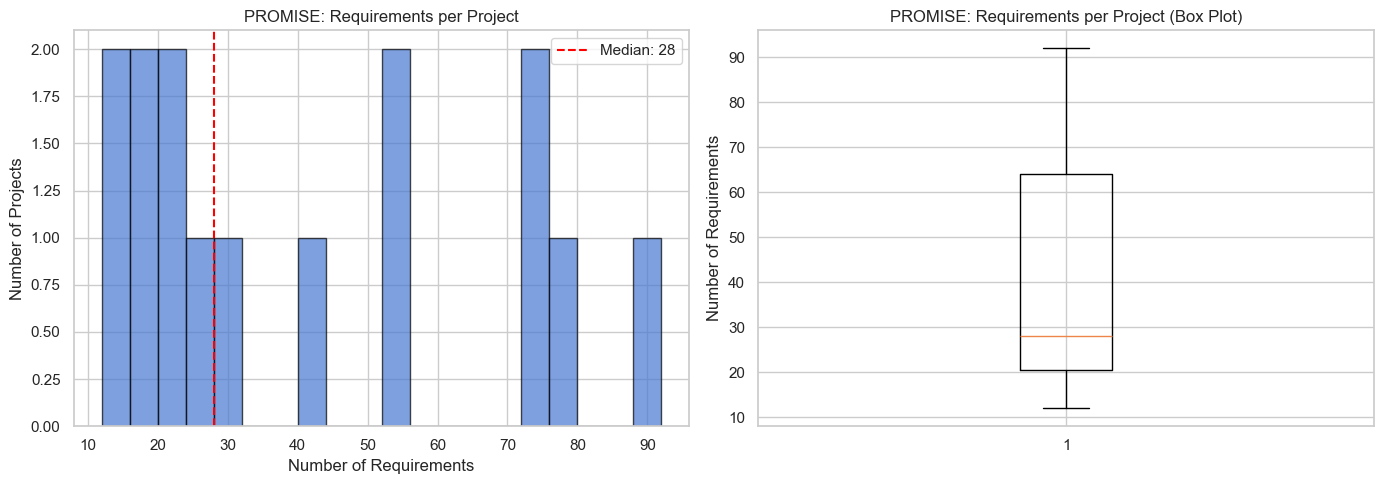


Summary statistics:
count    15.000000
mean     41.466667
std      27.189459
min      12.000000
25%      20.500000
50%      28.000000
75%      64.000000
max      92.000000
Name: count, dtype: float64

Outliers (> 2 std from mean):
Empty DataFrame
Columns: [ProjectID, count]
Index: []


In [3]:
# Plots and summary statistics showing requirements per project for PROMISE dataset
reqs_per_project = promise.groupby('ProjectID').size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(reqs_per_project['count'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Requirements')
axes[0].set_ylabel('Number of Projects')
axes[0].set_title('PROMISE: Requirements per Project')
axes[0].axvline(reqs_per_project['count'].median(), color='red', linestyle='--', label=f'Median: {reqs_per_project["count"].median():.0f}')
axes[0].legend()

axes[1].boxplot(reqs_per_project['count'], vert=True)
axes[1].set_ylabel('Number of Requirements')
axes[1].set_title('PROMISE: Requirements per Project (Box Plot)')

plt.tight_layout()
plt.show()

print(f'\nSummary statistics:')
print(reqs_per_project['count'].describe())
print(f'\nOutliers (> 2 std from mean):')
mean, std = reqs_per_project['count'].mean(), reqs_per_project['count'].std()
outliers = reqs_per_project[reqs_per_project['count'] > mean + 2 * std]
print(outliers)

### 1.2 Tag Frequency Distribution

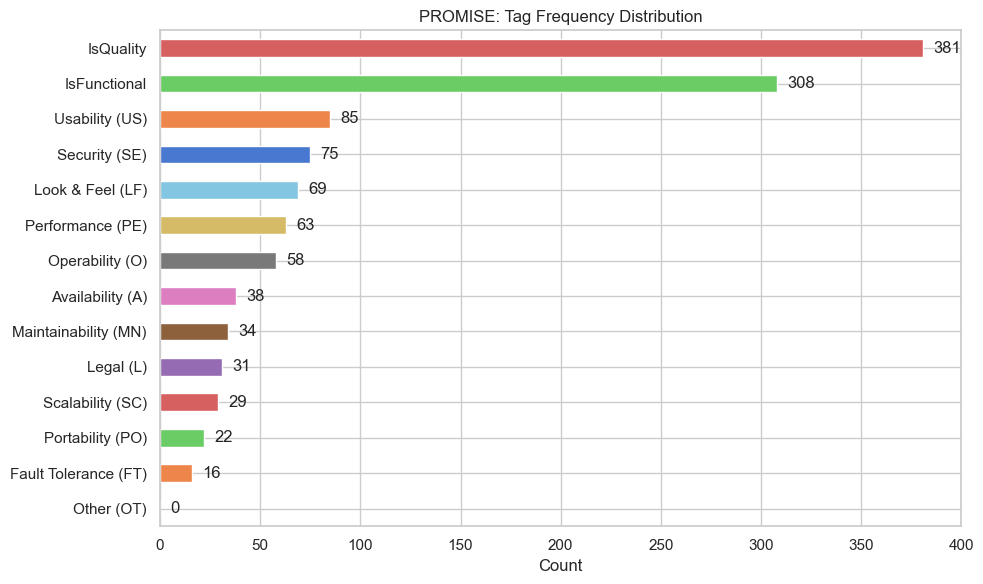


Functional vs Non-Functional split:
  Functional: 308 (49.5%)
  Non-Functional: 314 (50.5%)


In [4]:
# PROMISE distribution of requirement types (tags) and split between functional and non-functional requirements.
tag_cols = [
    'IsFunctional', 'IsQuality', 'Availability (A)', 'Fault Tolerance (FT)',
    'Legal (L)', 'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)',
    'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 'Security (SE)',
    'Usability (US)', 'Other (OT)'
]

tag_counts = promise[tag_cols].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
tag_counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(tag_counts)))
ax.set_xlabel('Count')
ax.set_title('PROMISE: Tag Frequency Distribution')
for i, v in enumerate(tag_counts.values):
    ax.text(v + 5, i, str(int(v)), va='center')
plt.tight_layout()
plt.show()

print(f'\nFunctional vs Non-Functional split:')
func_count = promise['IsFunctional'].sum()
print(f'  Functional: {func_count} ({func_count/len(promise)*100:.1f}%)')
print(f'  Non-Functional: {len(promise) - func_count} ({(len(promise) - func_count)/len(promise)*100:.1f}%)')

### 1.3 Requirement Text Length Distribution

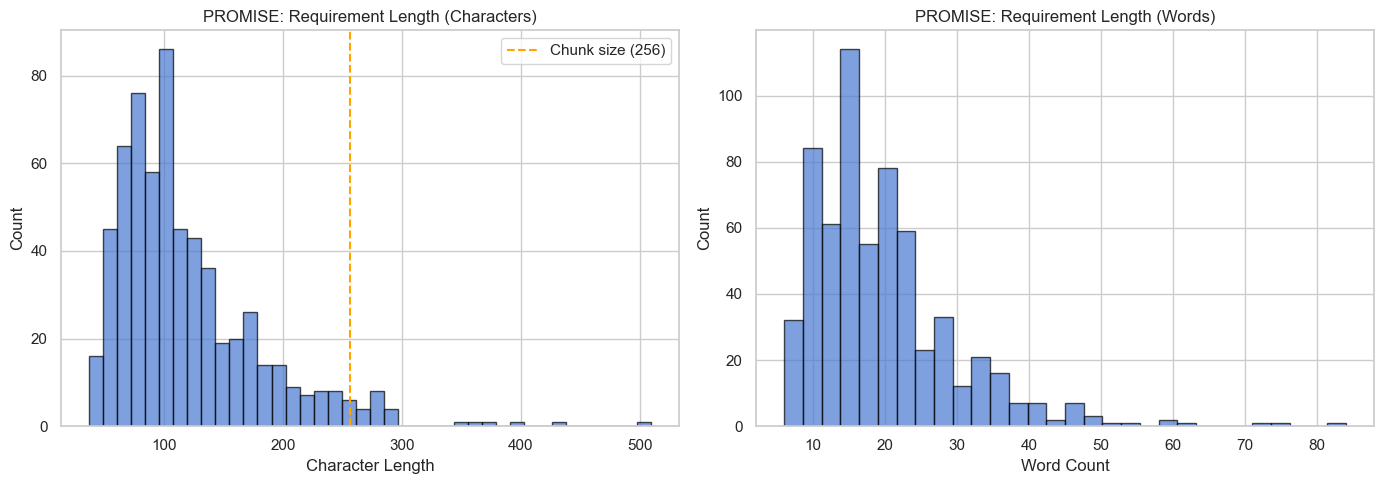

Character length stats:
count    622.000000
mean     119.329582
std       61.158060
min       37.000000
25%       76.000000
50%      104.000000
75%      142.000000
max      509.000000
Name: char_len, dtype: float64

% of requirements > 256 chars: 3.9%


In [6]:
# PROMISE requirements text length by characters and words.
promise['text_clean'] = promise['RequirementText'].str.strip("'")
promise['char_len'] = promise['text_clean'].str.len()
promise['word_count'] = promise['text_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(promise['char_len'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Count')
axes[0].set_title('PROMISE: Requirement Length (Characters)')
axes[0].axvline(256, color='orange', linestyle='--', label='Chunk size (256)')
axes[0].legend()

axes[1].hist(promise['word_count'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')
axes[1].set_title('PROMISE: Requirement Length (Words)')

plt.tight_layout()
plt.show()

print(f'Character length stats:')
print(promise['char_len'].describe())
print(f'\n% of requirements > 256 chars: {(promise["char_len"] > 256).mean()*100:.1f}%')

---
## 2. PURE Dataset EDA

### 2.1 Document Format Distribution

Total PURE requirement files: 61

Format distribution:
  .pdf: 45
  .docx: 14
  .html: 2


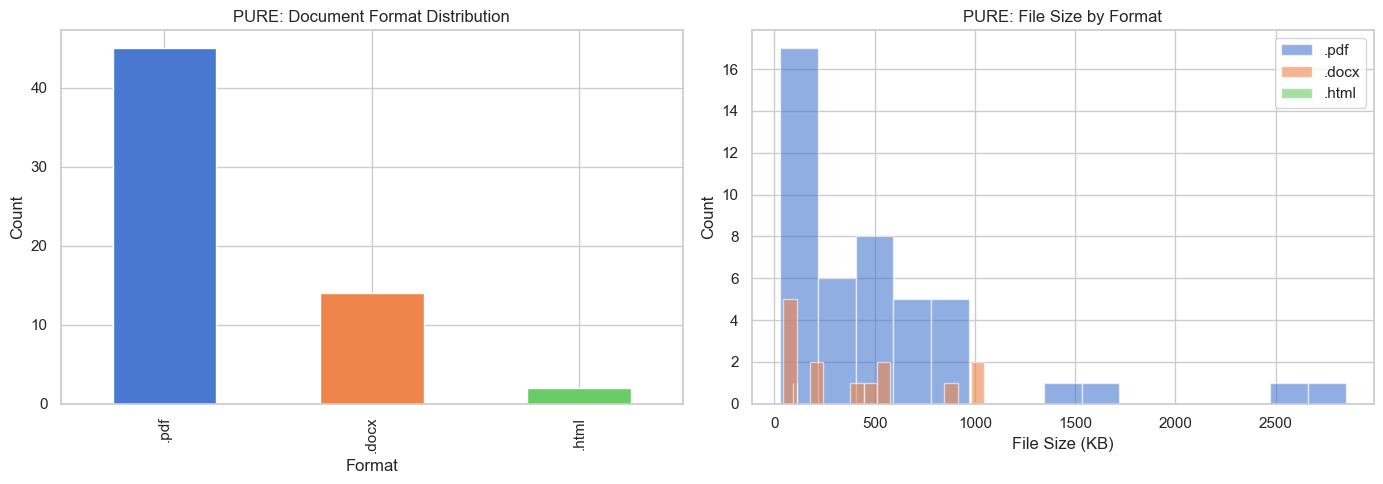

In [14]:
# PURE data distribution by document format and file size.
pure_files = [f for f in list(PURE_REQ_PATH.iterdir()) if f.is_file() and not f.name.startswith('.')]
pure_extensions = Counter(f.suffix.lower() for f in pure_files) 

print(f'Total PURE requirement files: {len([p for p in pure_files])}')
print(f'\nFormat distribution:')
for ext, count in sorted(pure_extensions.items(), key=lambda x: -x[1]):
    print(f'  {ext}: {count}')

# File size distribution
pure_sizes = [(f.name, f.suffix.lower(), f.stat().st_size / 1024) for f in pure_files]
pure_df = pd.DataFrame(pure_sizes, columns=['name', 'format', 'size_kb'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pure_df['format'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('muted'))
axes[0].set_title('PURE: Document Format Distribution')
axes[0].set_xlabel('Format')
axes[0].set_ylabel('Count')

for fmt in pure_df['format'].unique():
    subset = pure_df[pure_df['format'] == fmt]['size_kb']
    axes[1].hist(subset, bins=15, alpha=0.6, label=fmt)
axes[1].set_xlabel('File Size (KB)')
axes[1].set_ylabel('Count')
axes[1].set_title('PURE: File Size by Format')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.2 PURE XML Structure Analysis

In [24]:
# PURE XML file analysis: section stats and overall text length per file, parsed using xmltodict.
xml_files = sorted(PURE_XML_PATH.glob('*.xml'))
print(f'Total XML files: {len(xml_files)}')

xml_stats = []
for xml_file in xml_files:
    try:
        with open(xml_file, 'r', encoding='utf-8') as f:
            content = f.read()
        doc = xmltodict.parse(content)
        
        # Count the paragraph (<p>) elements (sections) in the XML files
        def count_p_elements(obj, depth=0):
            count = 0
            max_depth = depth
            if isinstance(obj, dict):
                if 'p' in obj:
                    p = obj['p']
                    if isinstance(p, list):
                        count += len(p)
                        for item in p:
                            c, d = count_p_elements(item, depth + 1)
                            count += c
                            max_depth = max(max_depth, d)
                    elif isinstance(p, dict):
                        count += 1
                        c, d = count_p_elements(p, depth + 1)
                        count += c
                        max_depth = max(max_depth, d)
                for k, v in obj.items():
                    if k != 'p':
                        c, d = count_p_elements(v, depth)
                        count += c
                        max_depth = max(max_depth, d)
            elif isinstance(obj, list):
                for item in obj:
                    c, d = count_p_elements(item, depth)
                    count += c
                    max_depth = max(max_depth, d)
            return count, max_depth
        
        p_count, max_depth = count_p_elements(doc)
        
        # Extract text length
        text_len = len(content)
        
        xml_stats.append({
            'file': xml_file.name,
            'sections': p_count,
            'max_depth': max_depth,
            'text_length': text_len
        })
    except Exception as e:
        print(f'Error parsing {xml_file.name}: {e}')
        xml_stats.append({'file': xml_file.name, 'sections': 0, 'max_depth': 0, 'text_length': 0})

xml_df = pd.DataFrame(xml_stats)
print(f'\nXML Structure Summary:')
print(xml_df[['file', 'sections', 'max_depth', 'text_length']].to_string(index=False))
print(f'\nAvg sections per doc: {xml_df["sections"].mean():.1f}')
print(f'Avg text length: {xml_df["text_length"].mean():.0f} chars')

Total XML files: 18

XML Structure Summary:
                            file  sections  max_depth  text_length
                0000 - cctns.xml        22          3        46770
              0000 - gamma j.xml       224          4        83576
               1995 - gemini.xml       189          5       165396
               1998 - themas.xml       125          6        43956
                  1999 - dii.xml        60          6        38581
                  1999 - tcs.xml       202          7       122604
            2003 - qheadache.xml       139          5        19605
            2005 - microcare.xml        46          6        45742
                 2005 - phin.xml       145          5        41966
        2006 - eirene sys 15.xml       745          6       137559
         2007 - get real 0.2.xml        43          3        16576
         2007-eirene_fun_7-2.xml       137          4       206644
                  2007-ertms.xml        71          4        64494
              2008

### 2.3 PURE Document Domain Categorization
Categorize documents by domain based on filename keywords for stratified splitting.

In [17]:
# List all unique PURE document names (deduplicating .doc/.docx pairs)
all_pure_names = set()
for f in pure_files:
    # Normalize: remove extension, strip year prefix for grouping
    base = f.stem
    if base.endswith('.doc'):
        base = base[:-4]  # Handle .doc.docx double extension edge case
    all_pure_names.add(base)

print(f'Unique PURE documents (deduped): {len(all_pure_names)}')
print('\nAll documents:')
for name in sorted(all_pure_names):
    print(f'  {name}')

Unique PURE documents (deduped): 60

All documents:
  0000 - inventory
  1999 - multi-mahjong
  2000 - nasa x38
  2001 - beyond
  2001 - ctc network
  2001 - elsfork
  2001 - esa
  2001 - hats
  2001 - libra
  2001 - npac
  2001 - space fractions
  2001 - telescope
  2002 - evla back
  2002 - evla corr
  2002 - sce api
  2003 - agentmom
  2003 - pnnl
  2003 - tachonet
  2004 - colorcast
  2004 - e-procurement
  2004 - grid bgc
  2004 - ijis
  2004 - jse
  2004 - philips
  2004 - rlcs
  2004 - sprat
  2004 - watcom
  2004 - watcom gui
  2005 - clarus high
  2005 - clarus low
  2005 - grid 3D
  2005 - nenios
  2005 - pontis
  2005 - triangle
  2005 - znix
  2006 - stewards
  2007 - central trading system
  2007 - e-store
  2007 - mdot
  2007 - nde
  2007 - nlm
  2007 - puget sound
  2007 - water use
  2008 - caiso
  2008 - viper
  2008 - virtual ed
  2008 - vub
  2009 - email
  2009 - gaia
  2009 - inventory 2.0
  2009 - library
  2009 - model manager
  2009 - peazip
  2009 - warc III
  

---
## 3. DevBench Dataset EDA

DevBench projects: 22
                    project   language  PRD.md_chars  PRD.md_lines  num_classes  UML_class.md_diagrams  UML_sequence.md_diagrams  architecture_design.md_chars
           area_calculation        cpp          3314            75            4                      0                         0                          1034
                  graph-cpp        cpp          5834            90            7                      0                         0                          4020
            logistic_system        cpp         11495           178            3                      0                         1                          7194
          people_management        cpp          5781           131            3                      1                         1                          2567
                   xlsx2csv        cpp          4500            93            5                      0                         0                          5693
    Actor_relationship_g

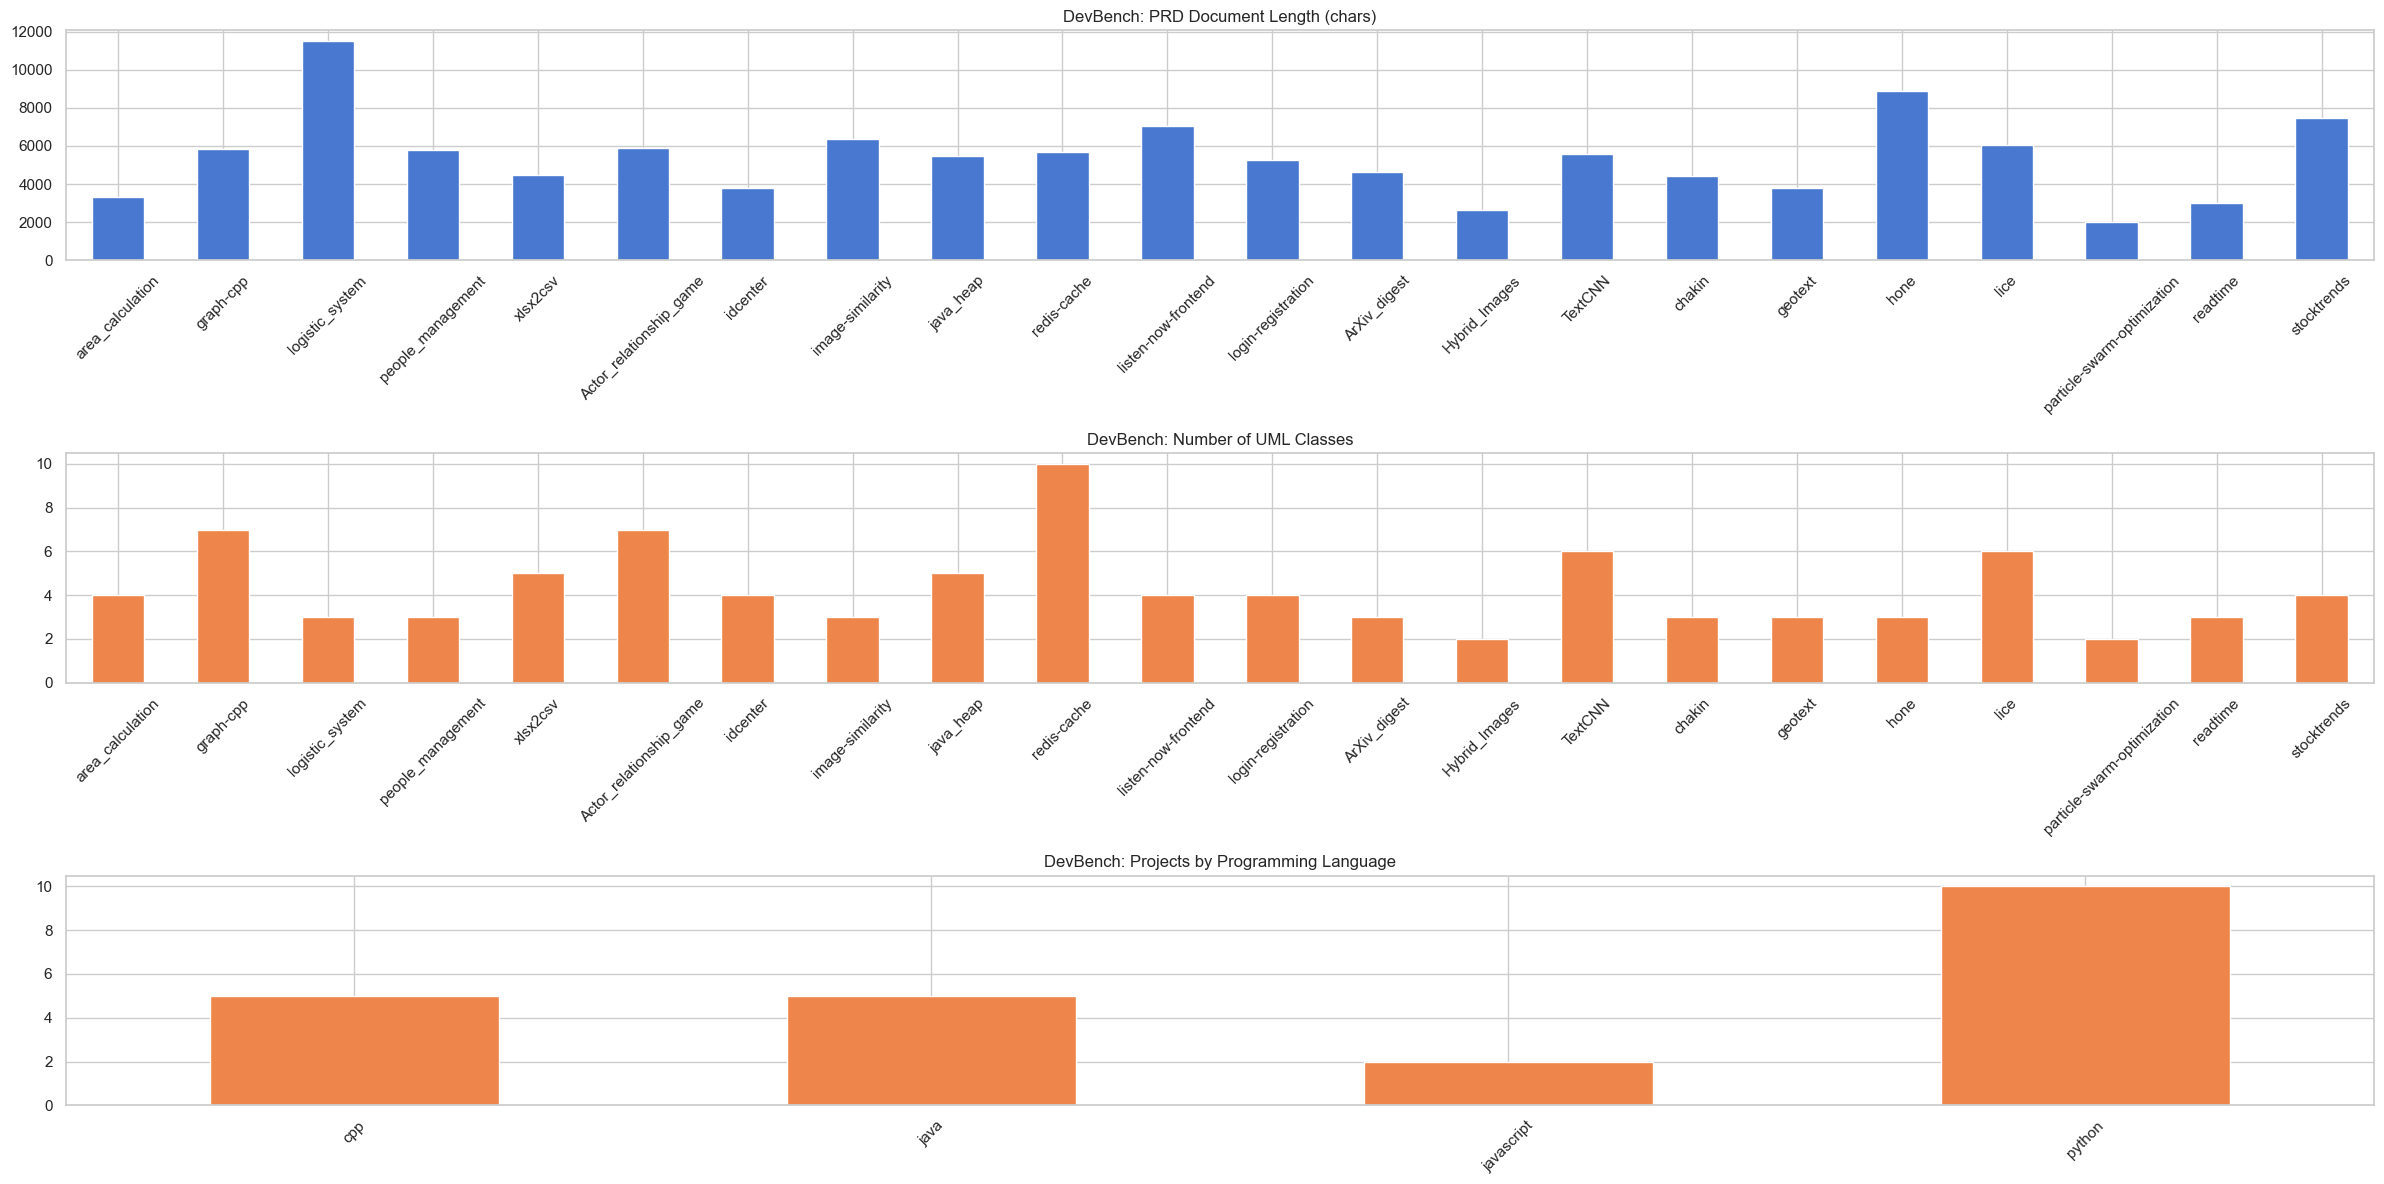

In [19]:
# Full DevBench dataset analysis: project stats, document lengths, and document distribution by programming language
devbench_projects = sorted([d for p in [DEVBENCH_PYTHON_PATH, DEVBENCH_JS_PATH, DEVBENCH_JAVA_PATH, DEVBENCH_CPP_PATH] for d in p.iterdir() if d.is_dir()])
print(f'DevBench projects: {len(devbench_projects)}')

devbench_stats = []
for project_dir in devbench_projects:
    stats = {'project': project_dir.name, 'language': project_dir.parent.name}
    
    for doc_type in ['PRD.md', 'UML_class.md', 'UML_sequence.md', 'architecture_design.md']:
        doc_path = project_dir / doc_type
        if doc_path.exists():
            content = doc_path.read_text(encoding='utf-8')
            stats[f'{doc_type}_chars'] = len(content)
            stats[f'{doc_type}_lines'] = content.count('\n') + 1
            
            # Count mermaid diagrams
            if doc_type in ('UML_class.md', 'UML_sequence.md'):
                mermaid_blocks = re.findall(r'```mermaid(.*?)```', content, re.DOTALL)
                stats[f'{doc_type}_diagrams'] = len(mermaid_blocks)
                
                # Count classes in class diagram
                if doc_type == 'UML_class.md':
                    classes = re.findall(r'class\s+(\w+)', content)
                    stats['num_classes'] = len(classes)
                    stats['class_names'] = classes
        else:
            stats[f'{doc_type}_chars'] = 0
            stats[f'{doc_type}_lines'] = 0
    
    devbench_stats.append(stats)

devbench_df = pd.DataFrame(devbench_stats)

# Display summary
display_cols = ['project', 'language', 'PRD.md_chars', 'PRD.md_lines', 'num_classes',
                'UML_class.md_diagrams', 'UML_sequence.md_diagrams',
                'architecture_design.md_chars']
existing_cols = [c for c in display_cols if c in devbench_df.columns]
print(devbench_df[existing_cols].to_string(index=False))

# PRD length comparison
fig, axes = plt.subplots(3, 1, figsize=(24, 12))

devbench_df.plot(x='project', y='PRD.md_chars', kind='bar', ax=axes[0],
                 legend=False, color=sns.color_palette('muted')[0])
axes[0].set_title('DevBench: PRD Document Length (chars)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

if 'num_classes' in devbench_df.columns:
    devbench_df.plot(x='project', y='num_classes', kind='bar', ax=axes[1],
                     legend=False, color=sns.color_palette('muted')[1])
    axes[1].set_title('DevBench: Number of UML Classes')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=45)
    
if 'language' in devbench_df.columns:
    # Count projects by language
    counts = devbench_df.groupby('language')['project'].count()

    # Draw the bar chart on the middle subplot
    counts.plot(
        kind='bar',
        ax=axes[2],
        legend=False,
        color=sns.color_palette('muted')[1]
    )

    # Title and tweaks
    axes[2].set_title('DevBench: Projects by Programming Language')
    axes[2].set_xlabel('')                # no x‑label needed
    axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 4. rSDE-Bench Dataset EDA

In [20]:
# EDA for the rSDE-Bench dataset (data comes as .md files): document sizes, and distribution by domain.
def analyze_rsde_spec(filepath):
    """Parse an rSDE-Bench markdown spec and extract key metrics."""
    content = filepath.read_text(encoding='utf-8')
    lines = content.split('\n')
    
    # Count pages (## 3.X sections)
    page_sections = re.findall(r'### \d+\.\d+\s+(.+)', content)
     
    # Count element IDs
    element_ids = re.findall(r'`(\w+)`\s*\(HTML', content)
    
    # Extract objective
    obj_match = re.search(r'## \d+\.\s*Objective\n(.+?)\n', content)
    objective = obj_match.group(1).strip() if obj_match else ''
    
    # Detect domain keywords
    name = filepath.stem
    
    return {
        'name': name,
        'type': 'website' if filepath.parent.name == 'website' else 'game',
        'chars': len(content),
        'lines': len(lines),
        'pages': len(page_sections),
        'element_ids': len(element_ids),
        'objective_len': len(objective),
    }

# Analyze all specs
rsde_stats = []
for spec_file in sorted(RSDE_WEBSITE_PATH.glob('*.md')):
    rsde_stats.append(analyze_rsde_spec(spec_file))
for spec_file in sorted(RSDE_GAME_PATH.glob('*.md')):
    rsde_stats.append(analyze_rsde_spec(spec_file))

rsde_df = pd.DataFrame(rsde_stats)
print(f'Total rSDE-Bench specs: {len(rsde_df)}')
print(f'  Website: {len(rsde_df[rsde_df["type"] == "website"])}')
print(f'  Game: {len(rsde_df[rsde_df["type"] == "game"])}')
print(f'\nWebsite specs summary:')
print(rsde_df[rsde_df['type'] == 'website'][['name', 'chars', 'pages', 'element_ids']].to_string(index=False))

Total rSDE-Bench specs: 53
  Website: 45
  Game: 8

Website specs summary:
                         name  chars  pages  element_ids
     CharitableGivingPlatform   3405      6           15
              DailyHealthTips   3083      3            0
              DailyJournalApp   3447      4            0
        DigitalArtworkGallery   2999      4            0
  DigitalStorytellingPlatform   2442      2            0
        EcoFriendlyLivingTips   5484      8            0
           ElderCareResources   3027      3            0
                 EventPlanner   4231      6            0
               ExpenseTracker   6179      7            0
            FitnessChallenges   4068      4            0
       FitnessEquipmentRental   5846     10            0
               FitnessTracker   5218      7            0
        FreelancerMarketplace   3895      6            0
        GardeningForBeginners   2982      3            0
      GourmetFoodSubscription   5935      7            0
             

### 4.1 Requirement Size Metrics
The rSDE-Bench requirements by number of pages and size of document.

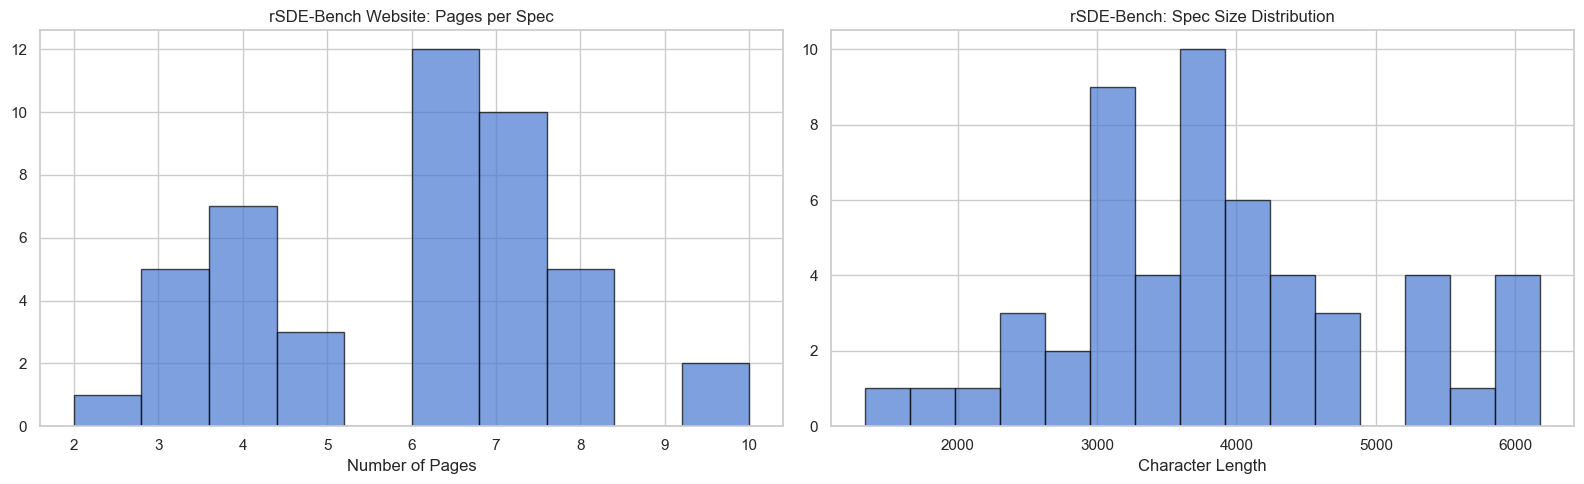

In [21]:
# Plots for page and text size distributions for rSDE-Bench dataset.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pages distribution
website_df = rsde_df[rsde_df['type'] == 'website']
axes[0].hist(website_df['pages'], bins=10, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Pages')
axes[0].set_title('rSDE-Bench Website: Pages per Spec')

# Spec size distribution
axes[1].hist(rsde_df['chars'], bins=15, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Character Length')
axes[1].set_title('rSDE-Bench: Spec Size Distribution')

plt.tight_layout()
plt.show()

### 4.2 Domain Tagging
Tag each spec with a domain categories.

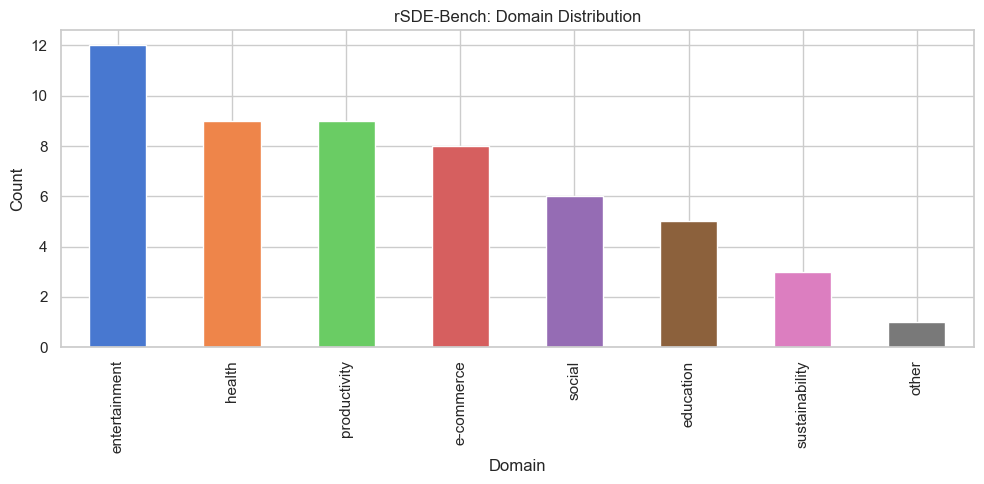


Domain breakdown:
  e-commerce (8): ExpenseTracker, FreelancerMarketplace, GourmetFoodSubscription, OnlineShoppingCenter, OnlineThriftStore, OnlineVintageMarket, PersonalFinanceBlog, RemoteInternshipMarketplace
  education (5): DigitalStorytellingPlatform, OnlineLibraryManagementSystem, PeerTutoringNetwork, SkillShare, VirtualBookPublishing
  entertainment (12): DigitalArtworkGallery, MotivationalQuotesApp, MovieRecommendationSystem, RecipeHub, battle_of_balls_game, bomerman_game, brick_breaker_game, ghostly_game, racing_game, sokoban_game, super_mario_game, tank_battle_game
  health (9): DailyHealthTips, ElderCareResources, FitnessChallenges, FitnessEquipmentRental, FitnessTracker, HealthConsultationPlatform, NutritionInformationHub, PetCareCommunity, VirtualWellnessRetreats
  other (1): CharitableGivingPlatform
  productivity (9): DailyJournalApp, EventPlanner, NoteTakingApp, OnlineTherapeuticJournaling, PersonalBlog, PortfolioSite, RemoteJobBoard, TaskManager, TravelDiary
  social 

In [ ]:
# rSDE-Bench dataset domain distribution.
DOMAIN_KEYWORDS = {
    'health': ['health', 'fitness', 'wellness', 'nutrition', 'therapy', 'care', 'elder'],
    'e-commerce': ['shop', 'market', 'store', 'thrift', 'vintage', 'subscription', 'rental', 'expense', 'finance'],
    'education': ['tutor', 'skill', 'book', 'library', 'publishing', 'story'],
    'social': ['community', 'forum', 'volunteer', 'match', 'collaborat', 'exchange', 'festival'],
    'productivity': ['task', 'note', 'journal', 'planner', 'blog', 'portfolio', 'diary', 'job', 'intern', 'remote'],
    'entertainment': ['movie', 'music', 'recipe', 'art', 'gallery', 'game', 'quotes', 'travel'],
    'sustainability': ['eco', 'green', 'garden'],
}

def tag_domain(name):
    name_lower = name.lower()
    for domain, keywords in DOMAIN_KEYWORDS.items():
        if any(kw in name_lower for kw in keywords):
            return domain
    return 'other'

rsde_df['domain'] = rsde_df['name'].apply(tag_domain)

fig, ax = plt.subplots(figsize=(10, 5))
rsde_df['domain'].value_counts().plot(kind='bar', ax=ax,
    color=sns.color_palette('muted', rsde_df['domain'].nunique()))
ax.set_title('rSDE-Bench: Domain Distribution')
ax.set_xlabel('Domain')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f'\nDomain breakdown:')
for domain in sorted(rsde_df['domain'].unique()):
    specs = rsde_df[rsde_df['domain'] == domain]['name'].tolist()
    print(f'  {domain} ({len(specs)}): {", ".join(specs)}')

---
## 5. Summary Statistics Table

In [ ]:
# Build summary table for documentation
summary_data = [
    {
        'Dataset': 'PROMISE',
        'Source Format': 'CSV',
        'Projects': 45,
        'Requirements': len(promise),
        'Planned Use': 'FAISS index'
    },
    {
        'Dataset': 'PURE XML',
        'Source Format': 'XML',
        'Projects': len(xml_files),
        'Requirements': f'{xml_df["sections"].sum()} sections',
        'Planned Use': 'FAISS index'
    },
    {
        'Dataset': 'PURE docs',
        'Source Format': 'PDF/DOCX/HTML',
        'Projects': '61',
        'Requirements': 'NA',
        'Planned Use': 'FAISS index and Goldens'
    },
    {
        'Dataset': 'rSDE-Bench',
        'Source Format': 'Markdown',
        'Projects': len(rsde_df),
        'Requirements': f'{rsde_df["element_ids"].sum()} elements',
        'Planned Use': 'Goldens (collector/analyzer)'
    },
    {
        'Dataset': 'DevBench',
        'Source Format': 'Markdown',
        'Projects': len(devbench_df),
        'Requirements': f'{devbench_df.get("num_classes", pd.Series([0])).sum():.0f} UML classes',
        'Planned Use': 'Goldens (designer/documenter/single/read)'
    },
]

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print(f'\n--- Dataset Overview ---')
print(summary_df.to_markdown(index=False))

   Dataset Source Format Projects   Requirements                               Planned Use
   PROMISE           CSV       45            622                               FAISS index
  PURE XML           XML       18  2698 sections                               FAISS index
 PURE docs PDF/DOCX/HTML       61             NA                   FAISS index and Goldens
rSDE-Bench      Markdown       53    15 elements              Goldens (collector/analyzer)
  DevBench      Markdown       22 94 UML classes Goldens (designer/documenter/single/read)

--- Dataset Overview ---
| Dataset    | Source Format   |   Projects | Requirements   | Planned Use                               |
|:-----------|:----------------|-----------:|:---------------|:------------------------------------------|
| PROMISE    | CSV             |         45 | 622            | FAISS index                               |
| PURE XML   | XML             |         18 | 2698 sections  | FAISS index                               |


---
## 6. Post-Processing EDA: Multi-Source Chunks

Run this section **after** rebuilding the FAISS index with `python -m src.rag.indexer`.

Total multi-source chunks: 5383

Chunks by source:
  pure_doc: 4115
  pure_xml: 846
  promise: 422


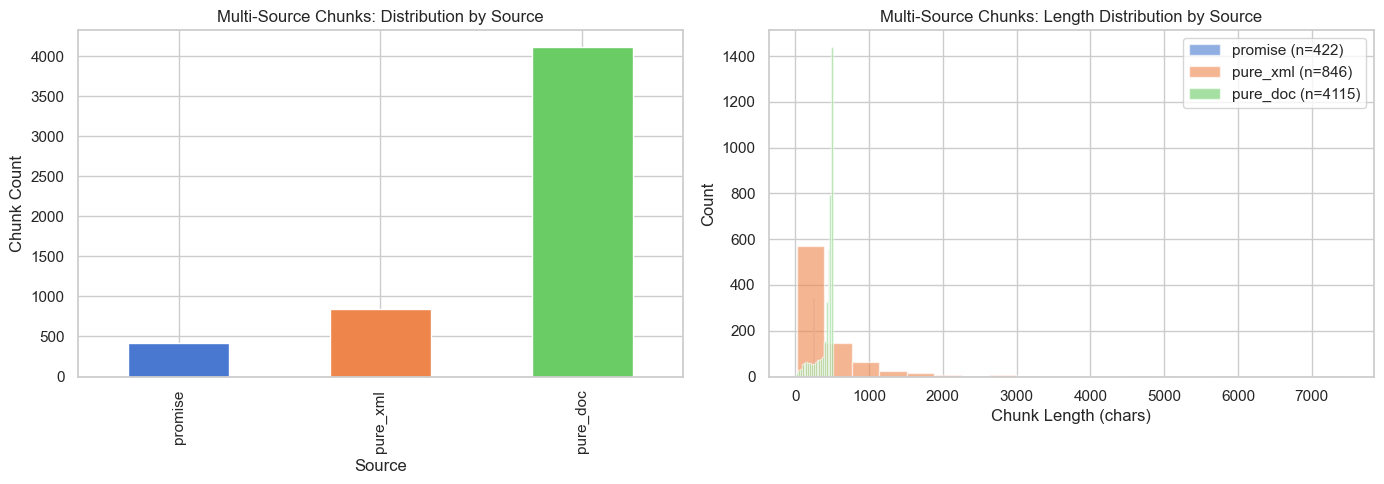


Chunk length stats by source:
           count        mean         std   min    25%    50%    75%     max
source                                                                     
promise    422.0  245.646919   24.276925  60.0  248.0  252.0  254.0   256.0
pure_doc  4115.0  424.018469  112.538874  13.0  415.0  469.0  497.0   512.0
pure_xml   846.0  434.793144  686.891755  21.0   76.0  226.5  502.0  7471.0


In [26]:
# Load the multi-source chunks (after rebuilding the index)
chunks_path = PREPROCESSED_PATH / 'requirement_chunks.json'
if chunks_path.exists():
    with open(chunks_path, 'r') as f:
        ms_chunks = json.load(f)

    print(f'Total multi-source chunks: {len(ms_chunks)}')

    # Source distribution
    source_counts = Counter(c.get('source', 'unknown') for c in ms_chunks)
    print(f'\nChunks by source:')
    for source, count in sorted(source_counts.items(), key=lambda x: -x[1]):
        print(f'  {source}: {count}')

    # Chunk length by source
    chunk_data = pd.DataFrame([{
        'source': c.get('source', 'unknown'),
        'length': len(c['chunk']),
        'source_id': c.get('source_id', ''),
    } for c in ms_chunks])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    source_counts_series = pd.Series(source_counts)
    source_counts_series.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted'))
    axes[0].set_title('Multi-Source Chunks: Distribution by Source')
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Chunk Count')

    for source in chunk_data['source'].unique():
        subset = chunk_data[chunk_data['source'] == source]['length']
        axes[1].hist(subset, bins=20, alpha=0.6, label=f'{source} (n={len(subset)})')
    axes[1].set_xlabel('Chunk Length (chars)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Multi-Source Chunks: Length Distribution by Source')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Per-source stats
    print(f'\nChunk length stats by source:')
    print(chunk_data.groupby('source')['length'].describe().to_string())
else:
    print('Multi-source chunks not yet generated. Run the indexer first.')